## GitHub Project 1

### Healthcare Data

In [1]:
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import date
import seaborn as sns

#### Reading the data

In [2]:
df = pd.read_csv("C:/Users/user/Downloads/archive/healthcare_dataset.csv")

In [3]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

#### Changing datetime for columns Date of Admission, Discharge Date

In [5]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])

In [6]:
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                55500 non-null  object        
 1   Age                 55500 non-null  int64         
 2   Gender              55500 non-null  object        
 3   Blood Type          55500 non-null  object        
 4   Medical Condition   55500 non-null  object        
 5   Date of Admission   55500 non-null  datetime64[ns]
 6   Doctor              55500 non-null  object        
 7   Hospital            55500 non-null  object        
 8   Insurance Provider  55500 non-null  object        
 9   Billing Amount      55500 non-null  float64       
 10  Room Number         55500 non-null  int64         
 11  Admission Type      55500 non-null  object        
 12  Discharge Date      55500 non-null  datetime64[ns]
 13  Medication          55500 non-null  object    

In [8]:
df.describe()

,Age,Date of Admission,Billing Amount,Room Number,Discharge Date
count,55500.000000,55500,55500.000000,55500.000000,55500
mean,51.539459,2021-11-01 01:02:22.443243008,25539.316097,301.134829,2021-11-16 13:15:20.821621504
min,13.000000,2019-05-08 00:00:00,-2008.492140,101.000000,2019-05-09 00:00:00
25%,35.000000,2020-07-28 00:00:00,13241.224652,202.000000,2020-08-12 00:00:00
50%,52.000000,2021-11-01 00:00:00,25538.069376,302.000000,2021-11-17 00:00:00
75%,68.000000,2023-02-03 00:00:00,37820.508436,401.000000,2023-02-18 00:00:00
max,89.000000,2024-05-07 00:00:00,52764.276736,500.000000,2024-06-06 00:00:00
std,19.602454,NaN,14211.454431,115.243069,NaN


#### Removing Negative Billing Amounts

In [9]:
negative_billing = df[df['Billing Amount'] < 0]
len(negative_billing)
print(f"The count of negatives is: {len(negative_billing)}")
print(f"The count of negatives is: {sum(negative_billing['Billing Amount'])}")

The count of negatives is: 108
The count of negatives is: -53924.534139323805


In [10]:
df = df[df['Billing Amount'] > 0]

In [11]:
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [12]:
df['Date of Admission'].dropna()

0       2024-01-31
1       2019-08-20
2       2022-09-22
3       2020-11-18
4       2022-09-19
           ...    
55495   2020-08-16
55496   2020-01-23
55497   2020-07-13
55498   2019-05-25
55499   2024-04-02
Name: Date of Admission, Length: 55392, dtype: datetime64[ns]

In [13]:
df['Discharge Date'].dropna()

0       2024-02-02
1       2019-08-26
2       2022-10-07
3       2020-12-18
4       2022-10-09
           ...    
55495   2020-09-15
55496   2020-02-01
55497   2020-08-10
55498   2019-05-31
55499   2024-04-29
Name: Discharge Date, Length: 55392, dtype: datetime64[ns]

#### Converting to string type 

In [14]:
df['Name'] = df['Name'].astype(str)
df.info()







<class 'pandas.core.frame.DataFrame'>
Index: 55392 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                55392 non-null  object        
 1   Age                 55392 non-null  int64         
 2   Gender              55392 non-null  object        
 3   Blood Type          55392 non-null  object        
 4   Medical Condition   55392 non-null  object        
 5   Date of Admission   55392 non-null  datetime64[ns]
 6   Doctor              55392 non-null  object        
 7   Hospital            55392 non-null  object        
 8   Insurance Provider  55392 non-null  object        
 9   Billing Amount      55392 non-null  float64       
 10  Room Number         55392 non-null  int64         
 11  Admission Type      55392 non-null  object        
 12  Discharge Date      55392 non-null  datetime64[ns]
 13  Medication          55392 non-null  object        


#### Forcing all names to be upper

In [15]:
df['Name'] = df['Name'].str.upper() 

In [16]:
unique_customers = df['Name'].unique

In [17]:
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,BOBBY JACKSON,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LESLIE TERRY,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DANNY SMITH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,ANDREW WATTS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,ADRIENNE BELL,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,ELIZABETH JACKSON,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYLE PEREZ,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATHER WANG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENNIFER JONES,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55392 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                55392 non-null  object        
 1   Age                 55392 non-null  int64         
 2   Gender              55392 non-null  object        
 3   Blood Type          55392 non-null  object        
 4   Medical Condition   55392 non-null  object        
 5   Date of Admission   55392 non-null  datetime64[ns]
 6   Doctor              55392 non-null  object        
 7   Hospital            55392 non-null  object        
 8   Insurance Provider  55392 non-null  object        
 9   Billing Amount      55392 non-null  float64       
 10  Room Number         55392 non-null  int64         
 11  Admission Type      55392 non-null  object        
 12  Discharge Date      55392 non-null  datetime64[ns]
 13  Medication          55392 non-null  object        


In [19]:
customer_pay  = df.groupby(by='Name')['Billing Amount'].sum()
customer_pay

Name
AARON ADAMS          26052.106404
AARON AGUIRRE        27087.560553
AARON ANDERSON       39804.658624
AARON ANDERSON MD    16846.415799
AARON ARCHER         21204.154371
                         ...     
ZOE BLACK            21654.260701
ZOE JACKSON          16668.258866
ZOE RODRIGUEZ        18048.184602
ZOE SMITH            33252.225130
ZOE WHITE            28747.964184
Name: Billing Amount, Length: 40167, dtype: float64

In [20]:
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,BOBBY JACKSON,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LESLIE TERRY,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DANNY SMITH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,ANDREW WATTS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,ADRIENNE BELL,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,ELIZABETH JACKSON,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYLE PEREZ,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATHER WANG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENNIFER JONES,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [21]:
cleaned_df = df.copy()

In [22]:
cleaned_df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,BOBBY JACKSON,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LESLIE TERRY,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DANNY SMITH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,ANDREW WATTS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,ADRIENNE BELL,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,ELIZABETH JACKSON,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYLE PEREZ,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATHER WANG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENNIFER JONES,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [23]:
cleaned_df['Staying Days'] = (cleaned_df['Discharge Date'] - cleaned_df['Date of Admission']).dt.days

In [24]:
cleaned_df.describe()

,Age,Date of Admission,Billing Amount,Room Number,Discharge Date,Staying Days
count,55392.000000,55392,55392.000000,55392.000000,55392,55392.000000
mean,51.538543,2021-11-01 03:08:47.209705472,25590.084632,301.119205,2021-11-16 15:21:25.268630528,15.508774
min,13.000000,2019-05-08 00:00:00,9.238787,101.000000,2019-05-09 00:00:00,1.000000
25%,35.000000,2020-07-28 00:00:00,13297.478682,202.000000,2020-08-12 00:00:00,8.000000
50%,52.000000,2021-11-01 00:00:00,25573.823359,302.000000,2021-11-17 00:00:00,15.000000
75%,68.000000,2023-02-03 00:00:00,37849.210062,401.000000,2023-02-18 00:00:00,23.000000
max,89.000000,2024-05-07 00:00:00,52764.276736,500.000000,2024-06-06 00:00:00,30.000000
std,19.602045,NaN,14178.657522,115.238552,NaN,8.659552


#### Finding the total length of stays

In [25]:
cleaned_df['Staying Days'].sum()

np.int64(859062)

#### Length of stay per gender

In [26]:
Total_stay = cleaned_df.groupby('Gender')['Staying Days'].sum().sort_values(ascending=False).reset_index()
Total_stay


,Gender,Staying Days
0,Male,430862
1,Female,428200


<Axes: xlabel='Gender', ylabel='Staying Days'>

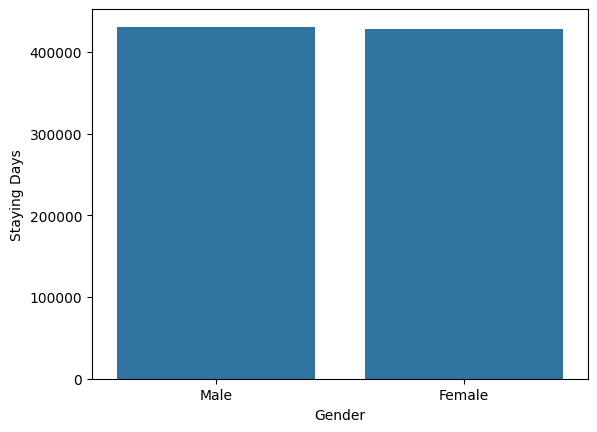

In [27]:
sns.barplot(x='Gender', y='Staying Days', data=Total_stay)

#### Average length of stay

In [28]:
average_stay = cleaned_df.groupby('Gender')['Staying Days'].mean().reset_index()
average_stay

,Gender,Staying Days
0,Female,15.477481
1,Male,15.539999


In [29]:
Inside_hospital = cleaned_df.groupby(by='Gender')[['Staying Days','Billing Amount']].sum().sort_values(by='Staying Days',ascending=False).reset_index()
Inside_hospital

,Gender,Staying Days,Billing Amount
0,Male,430862,7.112588e+08
1,Female,428200,7.062272e+08


#### Distribution of staying length

Text(0.5, 0, 'Length of stay (Days)')

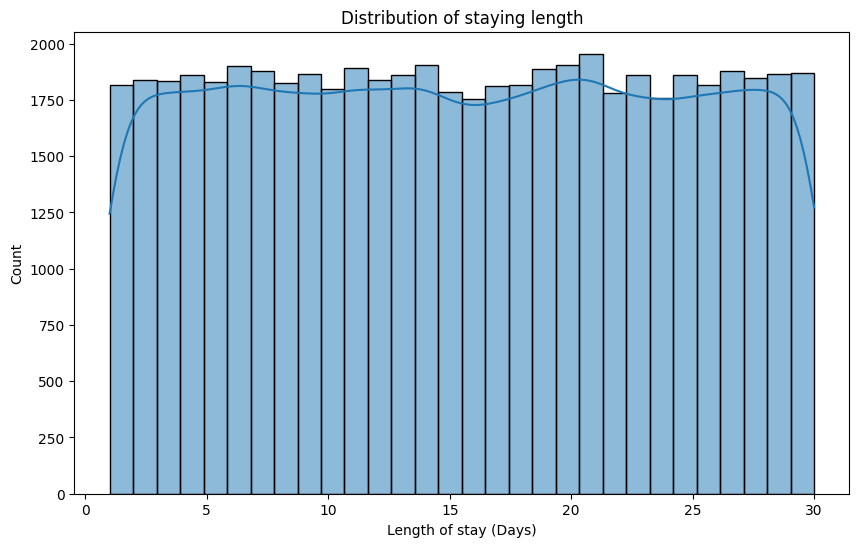

In [30]:
plt.figure(figsize=(10,6))
sns.histplot(cleaned_df['Staying Days'], bins=30, kde=True)
plt.title('Distribution of staying length')
plt.xlabel('Length of stay (Days)')

#### Biiling Amount per Medical Condition

C:\Users\user\AppData\Local\Temp\ipykernel_10864\2299584993.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Medical Condition', y='Billing Amount', data=cleaned_df,palette='pastel')


Text(0, 0.5, 'Billing Amount')

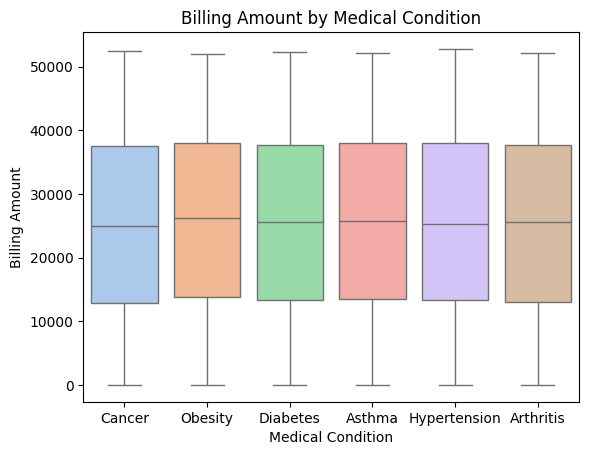

In [31]:
sns.boxplot(x='Medical Condition', y='Billing Amount', data=cleaned_df,palette='pastel')
plt.title('Billing Amount by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Billing Amount')

#### Top (20) patient staying length

In [32]:
customer_staying = cleaned_df.groupby(by='Name')[['Staying Days','Billing Amount']].sum().sort_values(by='Staying Days',ascending=False).reset_index()
customer_staying.head(20)

,Name,Staying Days,Billing Amount
0,MICHAEL SMITH,376,660173.089022
1,MICHAEL WILLIAMS,318,555240.698319
2,JAMES GARCIA,307,346601.993435
3,JAMES WILLIAMS,298,471240.445227
4,JAMES SMITH,296,468220.237192
5,JAMES BROWN,289,452411.246237
6,JOHN SMITH,266,373678.436266
7,KIMBERLY SMITH,265,308210.814286
8,MATTHEW JONES,247,327497.857234
9,ROBERT SMITH,245,573407.937591


#### Distribution of Billing Amount

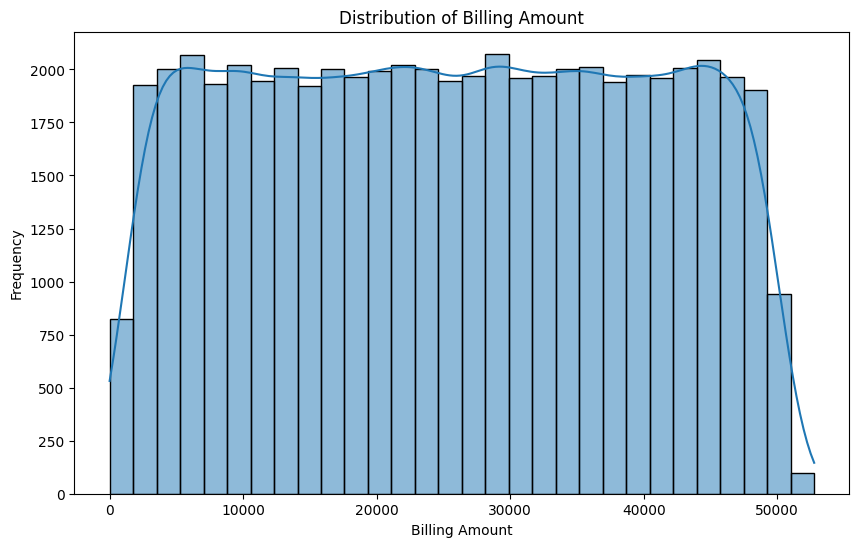

In [33]:
plt.figure(figsize=(10,6))
sns.histplot(cleaned_df['Billing Amount'], bins=30, kde=True)
plt.title('Distribution of Billing Amount')
plt.xlabel('Billing Amount')
plt.ylabel('Frequency')
plt.show()

#### Defining age bins for generations using 2024 as the base year
#### Gen Alpha: 2013-2024 (0-11)
#### Gen Z: 1997-2012 (12-27)
#### Millenials: 1981 - 1996 (28-43)
#### Gen X: 1965-1980 (44-59)
#### Boomers: 1946-1964 (60-78)
#### Rest: 1928-1945 (79-150)


In [34]:
bins = [0, 11, 27, 43, 59, 78, 150]
labels = ['Gen Alpha', 'Gen Z', 'Millennials', 'Gen X', 'Boomers', 'Rest']

In [35]:
cleaned_df['Age_category'] = pd.cut(cleaned_df['Age'], bins=bins, labels=labels)

In [36]:
cleaned_df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Staying Days,Age_category
0,BOBBY JACKSON,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2,Millennials
1,LESLIE TERRY,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6,Boomers
2,DANNY SMITH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15,Boomers
3,ANDREW WATTS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30,Millennials
4,ADRIENNE BELL,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20,Millennials
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,ELIZABETH JACKSON,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal,30,Millennials
55496,KYLE PEREZ,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal,9,Boomers
55497,HEATHER WANG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal,28,Millennials
55498,JENNIFER JONES,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal,6,Millennials


In [37]:
gen_count = cleaned_df['Age_category'].value_counts().reindex(labels)

C:\Users\user\AppData\Local\Temp\ipykernel_10864\3317934544.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gen_count.index, y=gen_count.values, palette='pastel')


Text(0, 0.5, 'Number of Patients')

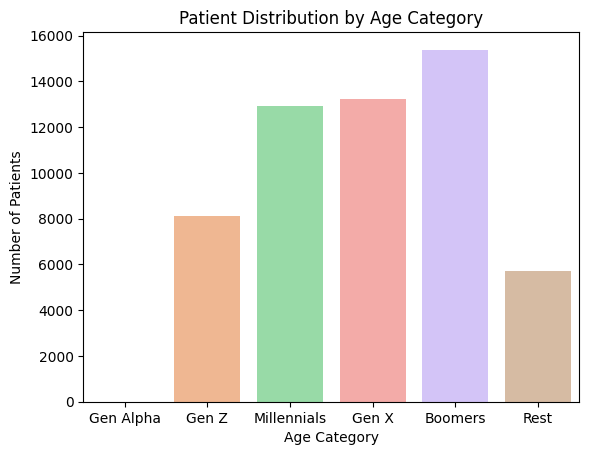

In [38]:
sns.barplot(x=gen_count.index, y=gen_count.values, palette='pastel')
plt.title('Patient Distribution by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Number of Patients')

In [56]:
most_common_condition = cleaned_df['Medical Condition'].value_counts()

In [44]:
print(f"The 5 most common conditions are: {most_common_condition}")

The 5 most common conditions are: Medical Condition
Arthritis       9297
Diabetes        9284
Hypertension    9224
Obesity         9212
Cancer          9208
Name: count, dtype: int64


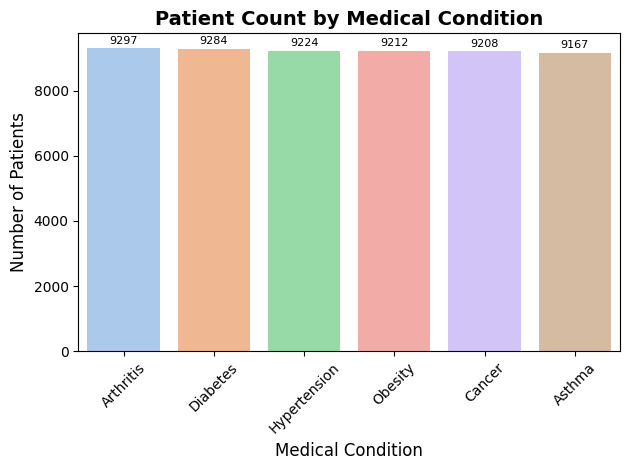

In [79]:
ax=sns.barplot(
            x=most_common_condition.index,
            y=most_common_condition.values,
            palette='pastel',
            hue=most_common_condition.index,
            legend=False)
for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=8)

plt.title('Patient Count by Medical Condition', fontsize=14, fontweight='bold')
plt.xlabel('Medical Condition', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [83]:
top_blood_type = cleaned_df['Blood Type'].value_counts()

In [84]:
print(top_blood_type)

Blood Type
A-     6953
A+     6939
AB+    6937
B+     6936
B-     6933
AB-    6929
O+     6905
O-     6860
Name: count, dtype: int64


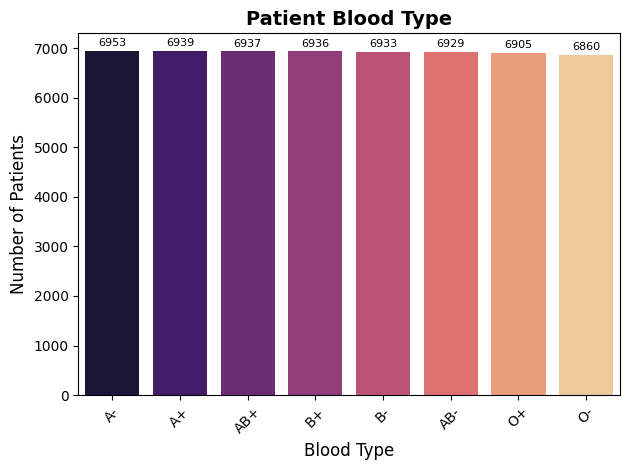

In [85]:
bt = sns.barplot(x=top_blood_type.index,
            y=top_blood_type.values,
            palette='magma',
            hue=top_blood_type.index,  
    legend=False
)
for value in bt.containers:
    bt.bar_label(value, padding=2, fontsize=8)
plt.title('Patient Blood Type', fontsize=14, fontweight='bold')
plt.xlabel('Blood Type', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()